Robustness evaluation


original: shape = (1941, 93)
-6 dB: shape = (1941, 93)
-3 dB: shape = (1941, 93)
+3 dB: shape = (1941, 93)
+6 dB: shape = (1941, 93)
Aantal numerieke feature-kolommen: 89


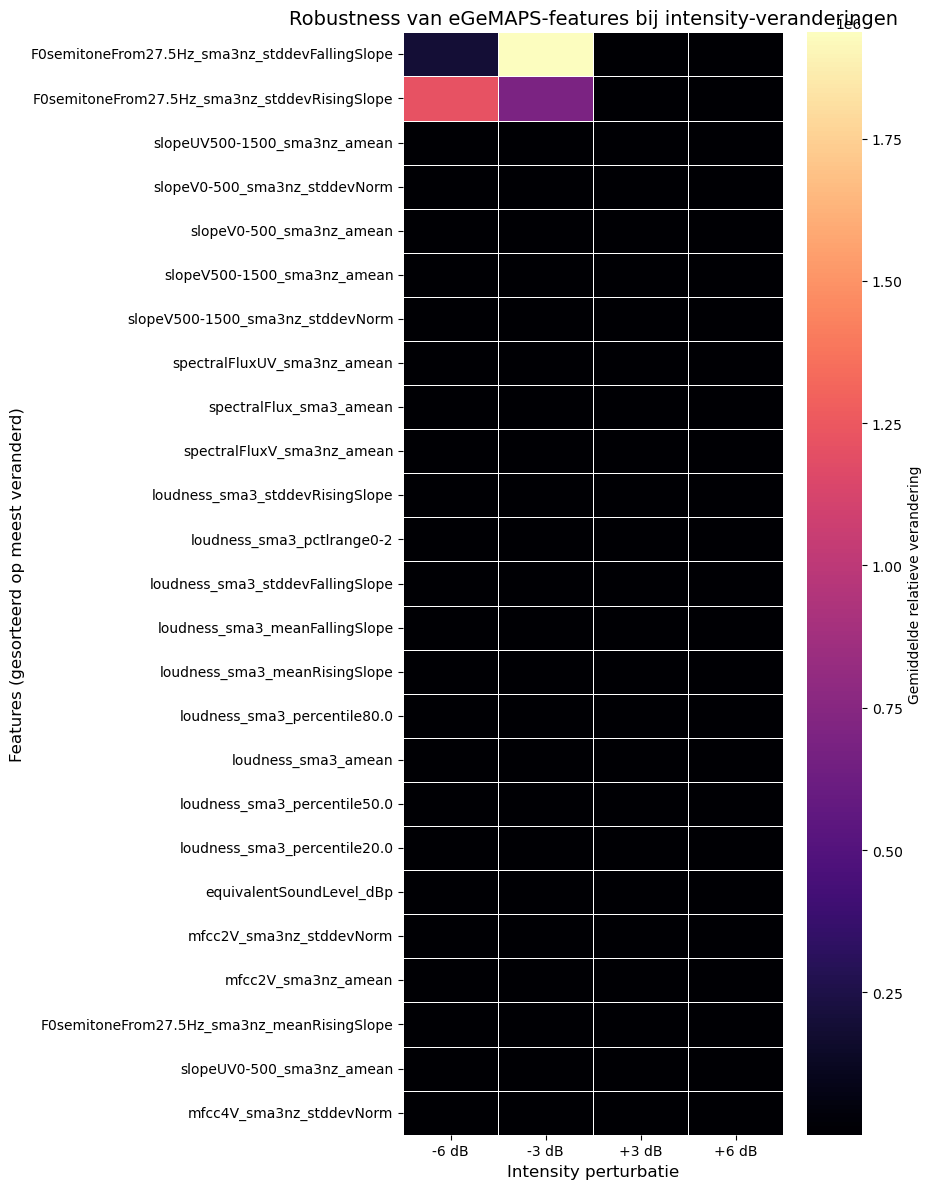

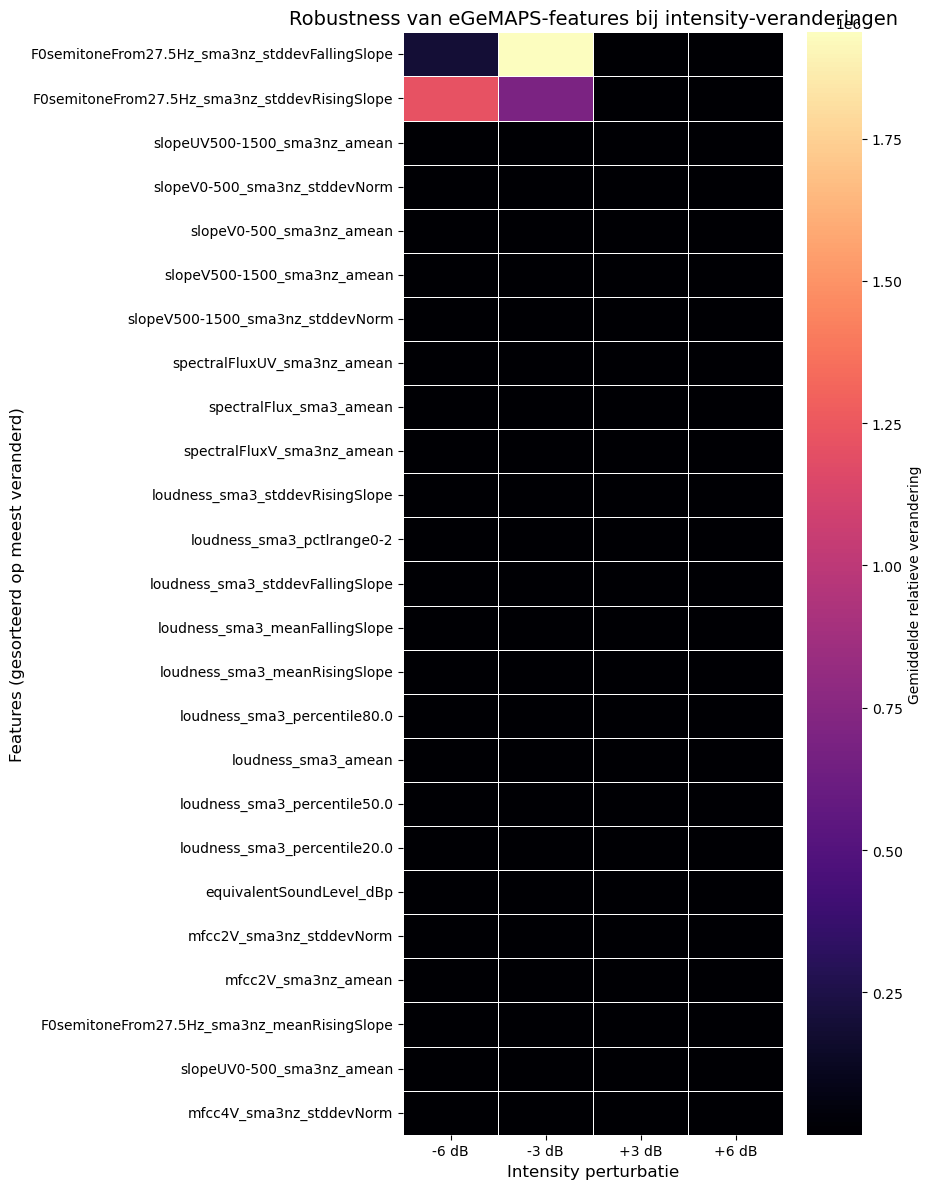

Heatmap-waarden opgeslagen in: C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\relative_difference_heatmap_values.csv
Heatmap opgeslagen in: C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\relative_difference_heatmap.png


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# =========================================================
# 1. PADEN NAAR BESTANDEN
# =========================================================
BASE_PATH = r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht"

files = {
    "original": os.path.join(BASE_PATH, "opensmile_wiener_features.csv"),
    "-6 dB": os.path.join(BASE_PATH, "opensmile_intensity_-6dB_features.csv"),
    "-3 dB": os.path.join(BASE_PATH, "opensmile_intensity_-3dB_features.csv"),
    "+3 dB": os.path.join(BASE_PATH, "opensmile_intensity_3dB_features.csv"),
    "+6 dB": os.path.join(BASE_PATH, "opensmile_intensity_6dB_features.csv"),
}


# =========================================================
# 2. DATA INLADEN
# =========================================================
dfs = {}
for key, path in files.items():
    df = pd.read_csv(path)
    dfs[key] = df
    print(f"{key}: shape = {df.shape}")


# =========================================================
# 3. CONTROLE OP BENODIGDE ID-KOLOMMEN
# =========================================================
required_id_cols = ["participant_id", "filename"]

for key, df in dfs.items():
    for col in required_id_cols:
        if col not in df.columns:
            raise ValueError(f"Kolom '{col}' niet gevonden in bestand: {key}")


# =========================================================
# 4. DATA UITLIJNEN OP participant_id + filename
# =========================================================
for key in dfs:
    dfs[key] = dfs[key].sort_values(by=["participant_id", "filename"]).reset_index(drop=True)

# Controle of de rijen echt overeenkomen
reference_ids = dfs["original"][["participant_id", "filename"]].copy()

for key in ["-6 dB", "-3 dB", "+3 dB", "+6 dB"]:
    compare_ids = dfs[key][["participant_id", "filename"]]
    if not reference_ids.equals(compare_ids):
        raise ValueError(f"De rijen in '{key}' komen niet overeen met het originele bestand.")


# =========================================================
# 5. FEATURE-KOLOMMEN SELECTEREN
#    Alleen numerieke kolommen, behalve ID-velden
# =========================================================
exclude_cols = ["participant_id", "filename", "file_path", "name"]
numeric_cols = dfs["original"].select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in exclude_cols]

print(f"Aantal numerieke feature-kolommen: {len(feature_cols)}")


# =========================================================
# 6. RELATIVE DIFFERENCE BEREKENEN
#    formule:
#    abs(perturbed - original) / (abs(original) + epsilon)
# =========================================================
epsilon = 1e-8
rel_diff_means = {}

original_features = dfs["original"][feature_cols].copy()

for condition in ["-6 dB", "-3 dB", "+3 dB", "+6 dB"]:
    perturbed_features = dfs[condition][feature_cols].copy()

    relative_difference = np.abs(perturbed_features - original_features) / (
        np.abs(original_features) + epsilon
    )

    # gemiddelde relatieve verandering per feature over alle opnames
    rel_diff_means[condition] = relative_difference.mean(axis=0)


# =========================================================
# 7. DATAFRAME MAKEN VOOR HEATMAP
# =========================================================
heatmap_df = pd.DataFrame(rel_diff_means)

# Gemiddelde verandering over alle condities heen
heatmap_df["mean_change"] = heatmap_df.mean(axis=1)

# Sorteren: meest veranderde features bovenaan
heatmap_df = heatmap_df.sort_values(by="mean_change", ascending=False)

# Helper-kolom weer verwijderen
heatmap_df = heatmap_df.drop(columns=["mean_change"])


# =========================================================
# 8. EVENTUEEL ALLEEN TOP N FEATURES TONEN
# =========================================================
top_n = 25   
heatmap_top = heatmap_df.head(top_n)


# =========================================================
# 9. HEATMAP MAKEN MET SEABORN
# =========================================================
plt.figure(figsize=(9, 12))

sns.heatmap(
    heatmap_top,
    cmap="magma",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Gemiddelde relatieve verandering"},
    annot=False
)

plt.title("Robustness van eGeMAPS-features bij intensity-veranderingen", fontsize=14)
plt.xlabel("Intensity perturbatie", fontsize=12)
plt.ylabel("Features (gesorteerd op meest veranderd)", fontsize=12)
plt.tight_layout()
plt.show()


# =========================================================
# 10. OPTIONEEL: OPSLAAN
# =========================================================
output_csv = os.path.join(BASE_PATH, "relative_difference_heatmap_values.csv")
heatmap_df.to_csv(output_csv)

output_png = os.path.join(BASE_PATH, "relative_difference_heatmap.png")
plt.figure(figsize=(9, 12))
sns.heatmap(
    heatmap_top,
    cmap="magma",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Gemiddelde relatieve verandering"},
    annot=False
)
plt.title("Robustness van eGeMAPS-features bij intensity-veranderingen", fontsize=14)
plt.xlabel("Intensity perturbatie", fontsize=12)
plt.ylabel("Features (gesorteerd op meest veranderd)", fontsize=12)
plt.tight_layout()
plt.savefig(output_png, dpi=300, bbox_inches="tight")
plt.show()

print(f"Heatmap-waarden opgeslagen in: {output_csv}")
print(f"Heatmap opgeslagen in: {output_png}")

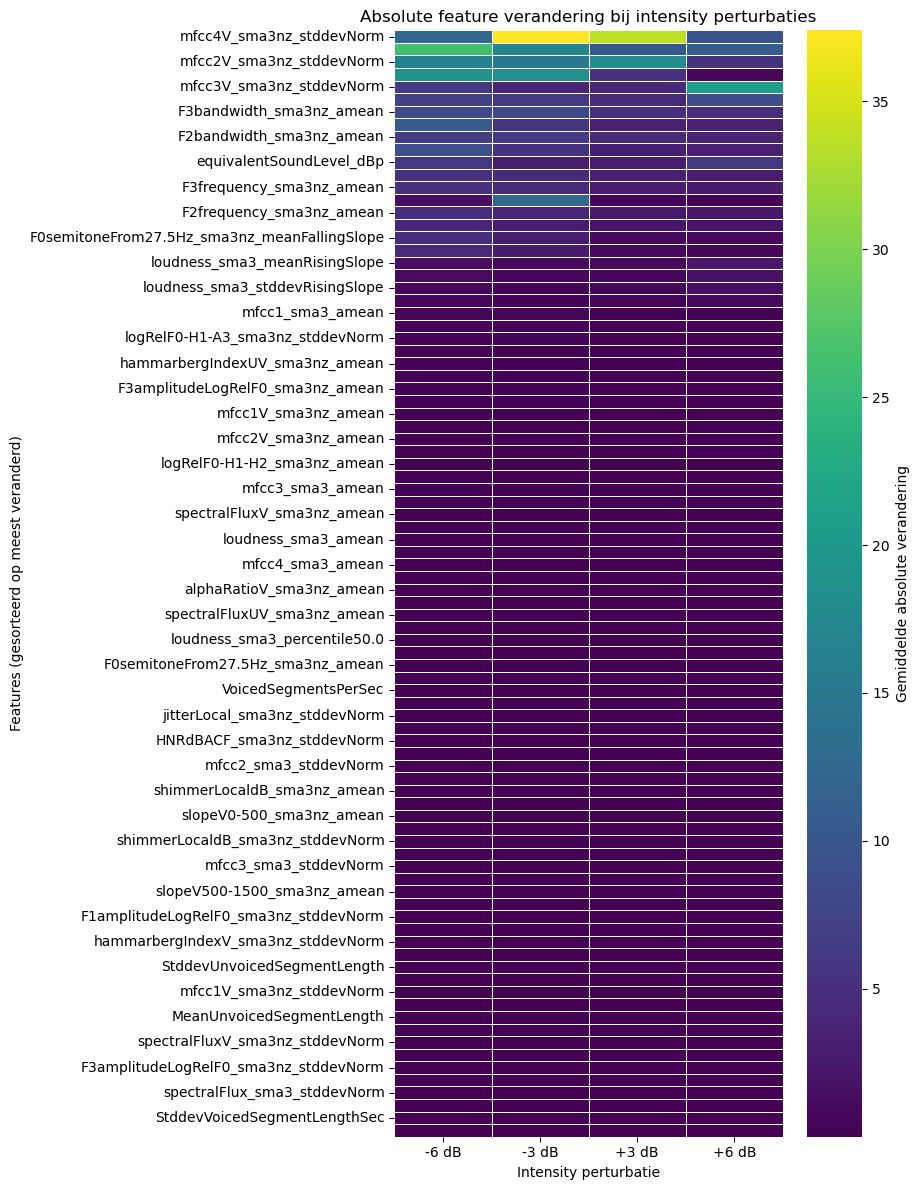

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# =========================================================
# 1. PADEN
# =========================================================
BASE_PATH = r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht"

files = {
    "original": os.path.join(BASE_PATH, "opensmile_wiener_features.csv"),
    "-6 dB": os.path.join(BASE_PATH, "opensmile_intensity_-6dB_features.csv"),
    "-3 dB": os.path.join(BASE_PATH, "opensmile_intensity_-3dB_features.csv"),
    "+3 dB": os.path.join(BASE_PATH, "opensmile_intensity_3dB_features.csv"),
    "+6 dB": os.path.join(BASE_PATH, "opensmile_intensity_6dB_features.csv"),
}


# =========================================================
# 2. DATA INLADEN
# =========================================================
dfs = {k: pd.read_csv(v) for k, v in files.items()}


# =========================================================
# 3. UITLIJNEN
# =========================================================
for k in dfs:
    dfs[k] = dfs[k].sort_values(by=["participant_id", "filename"]).reset_index(drop=True)

reference_ids = dfs["original"][["participant_id", "filename"]]

for key in ["-6 dB", "-3 dB", "+3 dB", "+6 dB"]:
    if not reference_ids.equals(dfs[key][["participant_id", "filename"]]):
        raise ValueError(f"Mismatch in {key}")


# =========================================================
# 4. FEATURES SELECTEREN
# =========================================================
exclude_cols = ["participant_id", "filename", "file_path", "name"]
numeric_cols = dfs["original"].select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in exclude_cols]


# =========================================================
# 5. ABSOLUTE DIFFERENCE
# =========================================================
abs_diff_means = {}

original_features = dfs["original"][feature_cols]

for condition in ["-6 dB", "-3 dB", "+3 dB", "+6 dB"]:
    perturbed_features = dfs[condition][feature_cols]

    abs_diff = np.abs(perturbed_features - original_features)

    abs_diff_means[condition] = abs_diff.mean(axis=0) #mean for the rows (files)


# =========================================================
# 6. DATAFRAME + SORTEREN
# =========================================================
heatmap_df = pd.DataFrame(abs_diff_means)

heatmap_df["mean_change"] = heatmap_df.mean(axis=1)
heatmap_df = heatmap_df.sort_values(by="mean_change", ascending=False)
heatmap_df = heatmap_df.drop(columns=["mean_change"])


# =========================================================
# 7. TOP N FEATURES
# =========================================================
top_n = 88
heatmap_top = heatmap_df.head(top_n)


# =========================================================
# 8. HEATMAP
# =========================================================
plt.figure(figsize=(9, 12))

sns.heatmap(
    heatmap_top,
    cmap="viridis",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Gemiddelde absolute verandering"},
    annot=False
)

plt.title("Absolute feature verandering bij intensity perturbaties")
plt.xlabel("Intensity perturbatie")
plt.ylabel("Features (gesorteerd op meest veranderd)")
plt.tight_layout()
plt.show()
